In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [3]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [5]:
from sklearn.model_selection import train_test_split

X = df.drop("charges", axis=1)
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [7]:
y_pred = model.predict(X_test)
y_pred

array([ 8969.55027444,  7068.74744287, 36858.41091155,  9454.67850053,
       26973.17345656, 10864.11316424,   170.28084136, 16903.45028662,
        1092.43093614, 11218.34318352, 28101.68455267,  9377.73460205,
        5263.0595179 , 38416.04221107, 40255.82339284, 37098.25353123,
       15240.39392306, 35912.88264434,  9112.52398703, 31461.92108909,
        3847.68845883, 10130.12001517,  2370.54189389,  7140.21550828,
       11301.76782638, 12961.65366224, 14509.47251876,  6159.8976107 ,
        9963.85857263,  2177.85718217,  9115.93673494, 13073.68932159,
        4561.82376202,  3408.20756033,  4459.81359745, 13032.06505076,
        1979.99357292,  8813.28303302, 33271.29124448, 32585.51583927,
        3908.76090964,  4326.10774721, 14142.81326533, 11423.45494846,
        8774.13955311, 12097.28051001,  5281.57353499,  3150.5596042 ,
       35494.46461214,  9150.1124786 , 15836.84575621,  2343.57470069,
       12364.78414194,  1482.29488266, 13389.06105161, 12573.57395972,
      

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5 # Calculate RMSE from MSE
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 4181.19
Mean Squared Error (MSE): 33596915.85
Root Mean Squared Error (RMSE): 5796.28
R-squared (R2): 0.78


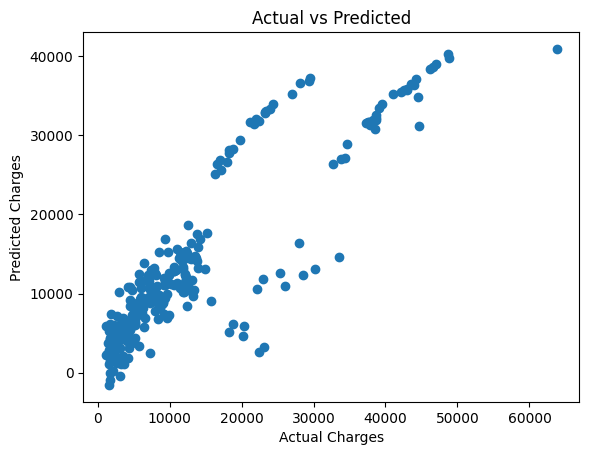

In [9]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted")
plt.show()

## Trying Ridge Regression

Ridge Model - Mean Absolute Error (MAE): 4193.59
Ridge Model - Mean Squared Error (MSE): 33645037.09
Ridge Model - Root Mean Squared Error (RMSE): 5800.43
Ridge Model - R-squared (R2): 0.78


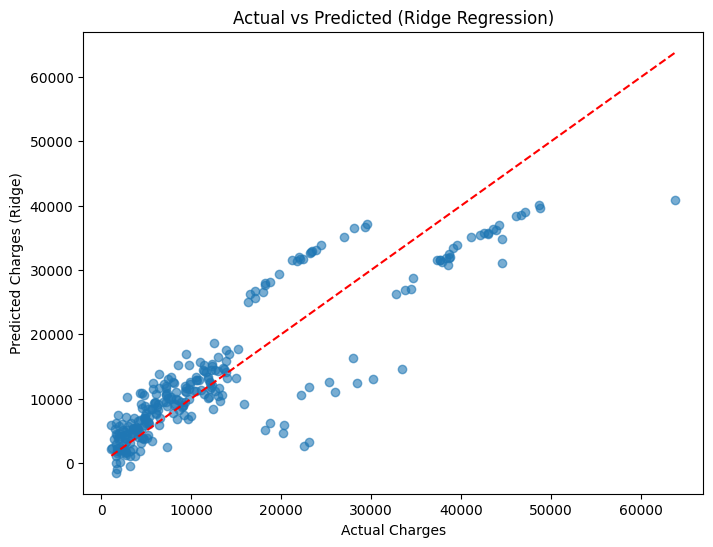

In [10]:
#Using Ridge to see how model fits

from sklearn.linear_model import Ridge

# Initialize and train the Ridge model
ridge_model = Ridge(alpha=1.0) # alpha is the regularization strength
ridge_model.fit(X_train, y_train)

# Make predictions
y_pred_ridge = ridge_model.predict(X_test)

# Evaluate the Ridge model
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = mse_ridge**0.5
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge Model - Mean Absolute Error (MAE): {mae_ridge:.2f}")
print(f"Ridge Model - Mean Squared Error (MSE): {mse_ridge:.2f}")
print(f"Ridge Model - Root Mean Squared Error (RMSE): {rmse_ridge:.2f}")
print(f"Ridge Model - R-squared (R2): {r2_ridge:.2f}")

# Plot actual vs predicted for Ridge
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_ridge, alpha=0.6)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges (Ridge)")
plt.title("Actual vs Predicted (Ridge Regression)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Ideal line
plt.show()

## Trying LASSO Regression

LASSO Model - Mean Absolute Error (MAE): 4182.43
LASSO Model - Mean Squared Error (MSE): 33605507.55
LASSO Model - Root Mean Squared Error (RMSE): 5797.03
LASSO Model - R-squared (R2): 0.78


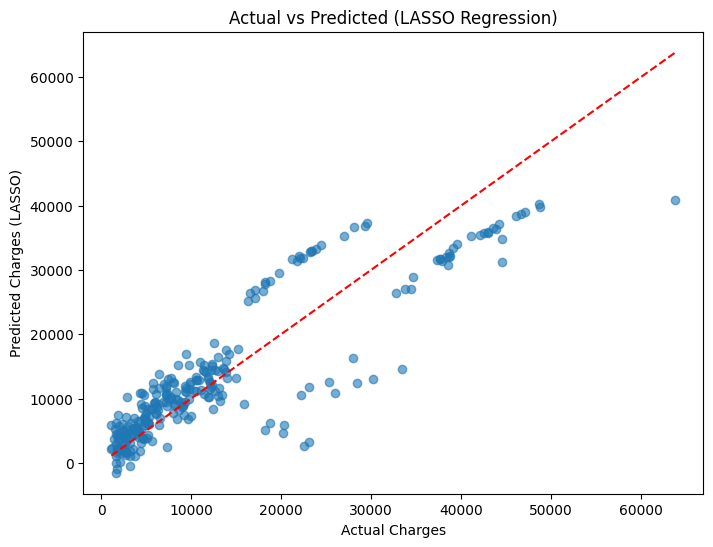

In [11]:
#Use LASSO to see how the model fits

from sklearn.linear_model import Lasso

# Initialize and train the LASSO model
lasso_model = Lasso(alpha=1.0) # alpha is the regularization strength
lasso_model.fit(X_train, y_train)

# Make predictions
y_pred_lasso = lasso_model.predict(X_test)

# Evaluate the LASSO model
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = mse_lasso**0.5
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"LASSO Model - Mean Absolute Error (MAE): {mae_lasso:.2f}")
print(f"LASSO Model - Mean Squared Error (MSE): {mse_lasso:.2f}")
print(f"LASSO Model - Root Mean Squared Error (RMSE): {rmse_lasso:.2f}")
print(f"LASSO Model - R-squared (R2): {r2_lasso:.2f}")

# Plot actual vs predicted for LASSO
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lasso, alpha=0.6)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges (LASSO)")
plt.title("Actual vs Predicted (LASSO Regression)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Ideal line
plt.show()

<Axes: xlabel='smoker_yes', ylabel='charges'>

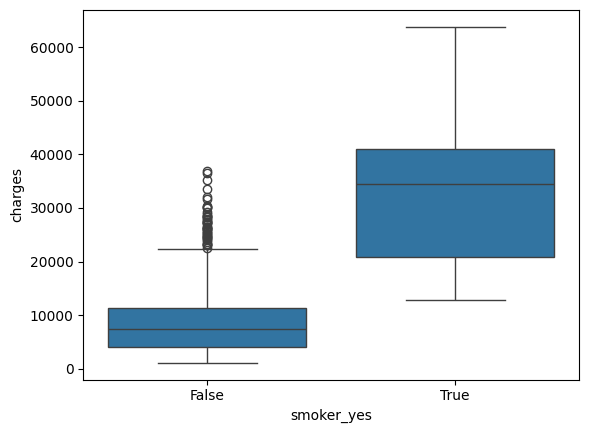

In [12]:
#See if smokers costs are higher than nonsmokers

import seaborn as sns

sns.boxplot(x="smoker_yes", y="charges", data=df)

You can compare the metrics and plots from these models to your initial Linear Regression model. Keep in mind that the `alpha` parameter (regularization strength) is important and often needs to be tuned for optimal performance. A higher `alpha` means stronger regularization.